### Predictive Maintenance Pipeline


In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import os   
from dotenv import load_dotenv

### Data Pulling from Consentium IoT

In [ ]:
load_dotenv(override=True) # Load environment variables from .env file, with override=True to ensure that any existing environment variables with the same names are overwritten by the values from the .env file. This is useful for development and testing purposes, allowing you to easily manage and switch between different sets of environment variables without affecting the global environment.
b_api_key = os.getenv("board_api_key").strip()  # Remove any leading/trailing whitespace  
r_api_key = os.getenv("receive_api_key").strip()   

# The Consentium REST API endpoint for receiving data
url = f"https://api.consentiumiot.com/getData" 
params = {
            "receiveKey": r_api_key,
            "boardKey": b_api_key,
            "limit": 50,  # Number of data points to retrieve
        }

In [ ]:

response = requests.get(url,params=params)

# Check if request was successful
if response.status_code == 200:
    data = response.json()
    feeds = data['feeds']
    board = data['board']

    print(f"Board name : {board['name']}")
    print(f"Sensors    : {board['info1']}, {board['info2']}, {board['info3']}")
    print(f"Total rows : {len(feeds)}")

    # Push feeds into dataframe
    df = pd.DataFrame(feeds)
    print(df.head())
    print(df.columns.tolist())

else:
    print(f"Failed to fetch data: {response.status_code}")
    df = pd.DataFrame()  # empty fallback



Board name : esp32
Sensors    : Accel_x, Accel_y, Accel_z
Total rows : 508
                   updated_at  value1  value2  value3  value4  value5
0  2026-04-10T09:57:02.578000    0.04    0.19    1.11   29.33    7.85
1  2026-04-10T09:57:09.109000    0.03    0.19    1.12   83.09    7.85
2  2026-04-10T09:57:15.561000    0.04    0.20    1.11   24.44    7.85
3  2026-04-10T09:57:22.024000    0.03    0.20    1.11   43.99    7.85
4  2026-04-10T09:57:29.853000    0.04    0.20    1.12  117.30    7.85
['updated_at', 'value1', 'value2', 'value3', 'value4', 'value5']


In [ ]:
df = df.rename(columns={
    'updated_at': 'timestamp',
    'value1':     'accel_x',
    'value2':     'accel_y',
    'value3':     'accel_z',
    'value4':     'strain',
    'value5':     'distance'
})

# Convert types
# Convert UTC timestamp to IST
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Kolkata')

# Remove timezone info if you don't need it displayed
df['timestamp'] = df['timestamp'].dt.tz_localize(None)
df['accel_x']   = pd.to_numeric(df['accel_x'], errors='coerce')
df['accel_y']   = pd.to_numeric(df['accel_y'], errors='coerce')
df['accel_z']   = pd.to_numeric(df['accel_z'], errors='coerce')
df['strain']    = pd.to_numeric(df['strain'], errors='coerce')
df['distance']  = pd.to_numeric(df['distance'], errors='coerce')


# Add window_id
df['window_id'] = df.index + 1


# Sort by timestamp ascending
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.tail(50).reset_index(drop=True)

# Reassign window_id after slicing
df['window_id'] = df.index + 1

df

,timestamp,accel_x,accel_y,accel_z,strain,distance,window_id
0,2026-04-10 16:26:22.293,0.06,0.05,1.15,14.66,8.82,1
1,2026-04-10 16:26:28.655,0.07,0.00,1.14,39.10,7.21,2
2,2026-04-10 16:26:35.232,0.07,0.00,1.14,19.55,7.21,3
3,2026-04-10 16:26:41.901,0.08,0.01,1.15,29.33,7.21,4
4,2026-04-10 16:26:48.527,0.07,0.01,1.16,4.89,7.21,5
5,2026-04-10 16:26:55.110,0.06,0.01,1.17,24.44,7.21,6
6,2026-04-10 16:27:01.819,0.06,0.00,1.14,14.66,7.21,7
7,2026-04-10 16:27:08.800,0.07,0.00,1.15,78.20,7.21,8
8,2026-04-10 16:27:15.735,0.07,0.00,1.16,53.76,7.21,9
9,2026-04-10 16:27:22.325,0.06,0.00,1.14,43.99,7.21,10


### Kalman Filter Implementation

In [ ]:
def kalman_filter(noisy_data, Q, R,x_est, P):

    kalman_estimates = []
    for z in noisy_data:
        # Prediction step
        P_pred = P + Q

        # Update step
        K = P_pred / (P_pred + R)
        x_est = x_est + K * (z - x_est)
        P = (1 - K) * P_pred

        kalman_estimates.append(x_est)
    return kalman_estimates


Q = 0.12  # Process noise covariance
R = 0.25   # Measurement noise covariance

x_est = 0.0   # Initial state estimate
P = 1.0       # Initial error covariance


sensor_columns = [
    'accel_x', 
    'accel_y', 
    'accel_z',
    'strain',
    'distance'
]

# 3. Loop through them and create new "filtered" columns
for col in sensor_columns:
    new_col_name = f"filtered_{col}"
    
    # We apply the filter and assign it to the new column
    df[new_col_name] = kalman_filter(df[col],Q,R,x_est,P)

# Display the first few rows of the updated DataFrame
df['accel_total_rms'] = np.sqrt(df['filtered_accel_x']**2 + df['filtered_accel_y']**2 + df['filtered_accel_z']**2)
df.head()

,timestamp,accel_x,accel_y,accel_z,strain,distance,window_id,filtered_accel_x,filtered_accel_y,filtered_accel_z,filtered_strain,filtered_distance,accel_total_rms
0,2026-04-10 16:26:22.293,0.06,0.05,1.15,14.66,8.82,1,0.049051,0.040876,0.940146,11.984818,7.210511,0.942312
1,2026-04-10 16:26:28.655,0.07,0.00,1.14,39.10,7.21,2,0.060882,0.017791,1.053013,27.298056,7.210222,1.054922
2,2026-04-10 16:26:35.232,0.07,0.00,1.14,19.55,7.21,3,0.065541,0.008701,1.097458,23.339248,7.210109,1.099448
3,2026-04-10 16:26:41.901,0.08,0.01,1.15,29.33,7.21,4,0.072737,0.009348,1.123610,26.320996,7.210055,1.126000
4,2026-04-10 16:26:48.527,0.07,0.01,1.16,4.89,7.21,5,0.071384,0.009670,1.141600,15.726185,7.210028,1.143870


In [ ]:
# # Plotting the original and filtered data for one of the sensor columns
# plt.figure(figsize=(12, 6))
# plt.plot(df['strain_s2_microstrain'], label='Original strain_s2_microstrain', alpha=0.5)
# plt.plot(df['filtered_strain_s2_microstrain'], label='Filtered strain_s2_microstrain', alpha=0.8)
# plt.title('Original vs Filtered strain_s2_microstrain')
# plt.xlabel('Time')
# plt.ylabel('Value')
# plt.legend()
# plt.show()

### Threshold Values...

In [ ]:
accel_threshold = 1.16  # Threshold for total RMS acceleration in g
strain_threshold = 100  # Threshold for strain in microstrain
us_threshold = 6 # Threshold for distance in cm


### Raw Signal Processing

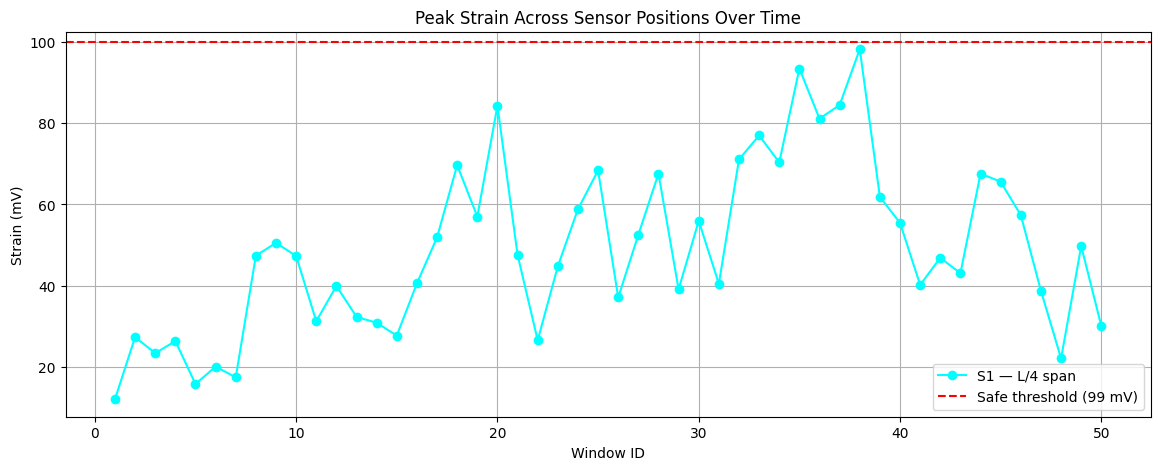

In [ ]:

# Peak strain comparison across all 3 sensors 
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['filtered_strain'],
         marker='o', label='S1 — L/4 span', color='cyan')
plt.axhline(y=strain_threshold, color='red', linestyle='--', label='Safe threshold (99 mV)') # Adding a horizontal line to indicate the safe threshold
plt.title('Peak Strain Across Sensor Positions Over Time')
plt.xlabel('Window ID')
plt.ylabel('Strain (mV)')
plt.legend()
plt.grid(True)
plt.show()





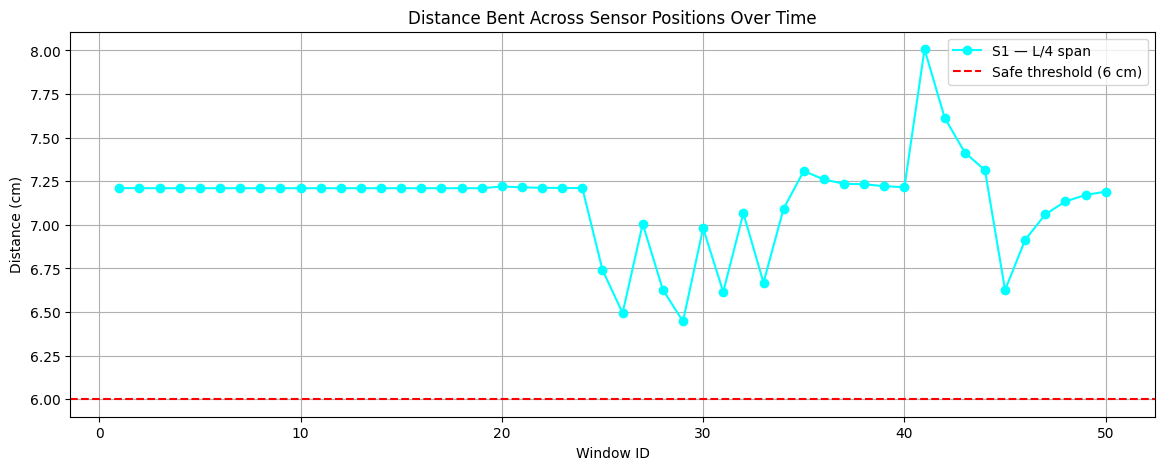

In [ ]:
# distance
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['filtered_distance'],
         marker='o', label='S1 — L/4 span', color='cyan')
plt.axhline(y=us_threshold, color='red', linestyle='--', label='Safe threshold (6 cm)') # Adding a horizontal line to indicate the safe threshold
plt.title('Distance Bent Across Sensor Positions Over Time')
plt.xlabel('Window ID')
plt.ylabel('Distance (cm)')
plt.legend()
plt.grid(True)
plt.show()

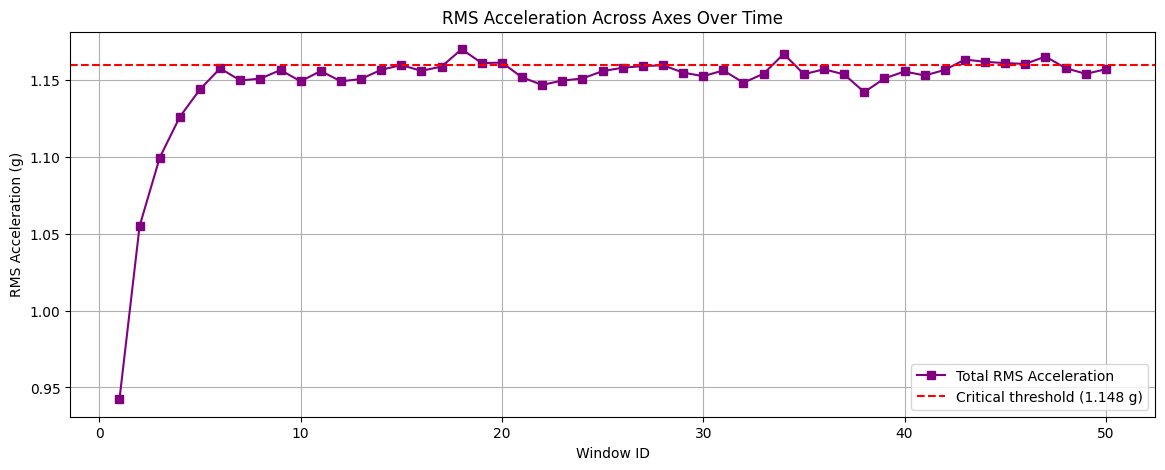

In [ ]:
# RMS acceleration across all 3 axes 
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['accel_total_rms'],
         marker='s', label='Total RMS Acceleration', color='purple')
plt.axhline(y=accel_threshold, color='red', linestyle='--', label='Critical threshold (1.148 g)') # Adding a horizontal line to indicate the critical threshold
plt.title('RMS Acceleration Across Axes Over Time')
plt.xlabel('Window ID')
plt.ylabel('RMS Acceleration (g)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# DataFrame Update
df.drop(['accel_x', 'accel_y', 'accel_z','strain','distance'], axis=1, inplace=True)
df.head()


,timestamp,window_id,filtered_accel_x,filtered_accel_y,filtered_accel_z,filtered_strain,filtered_distance,accel_total_rms
0,2026-04-10 16:26:22.293,1,0.049051,0.040876,0.940146,11.984818,7.210511,0.942312
1,2026-04-10 16:26:28.655,2,0.060882,0.017791,1.053013,27.298056,7.210222,1.054922
2,2026-04-10 16:26:35.232,3,0.065541,0.008701,1.097458,23.339248,7.210109,1.099448
3,2026-04-10 16:26:41.901,4,0.072737,0.009348,1.123610,26.320996,7.210055,1.126000
4,2026-04-10 16:26:48.527,5,0.071384,0.009670,1.141600,15.726185,7.210028,1.143870


### Independent Anomaly Detection

In [ ]:
# Anomaly detection based on thresholds

df['accel_anomaly'] = df['accel_total_rms'] > accel_threshold
# Displaying the anomalies detected
anomalies = df[df['accel_anomaly']]

df['strain_anomaly'] = df['filtered_strain'] > strain_threshold
# Displaying the anomalies detected
anomalies = df[df['strain_anomaly']] 

df['distance_anomaly'] = df['filtered_distance'] < us_threshold
# Displaying the anomalies detected
anomalies = df[df['distance_anomaly']]


print("Anomalies detected:")

anomalies


Anomalies detected:


,timestamp,window_id,filtered_accel_x,filtered_accel_y,filtered_accel_z,filtered_strain,filtered_distance,accel_total_rms,accel_anomaly,strain_anomaly,distance_anomaly


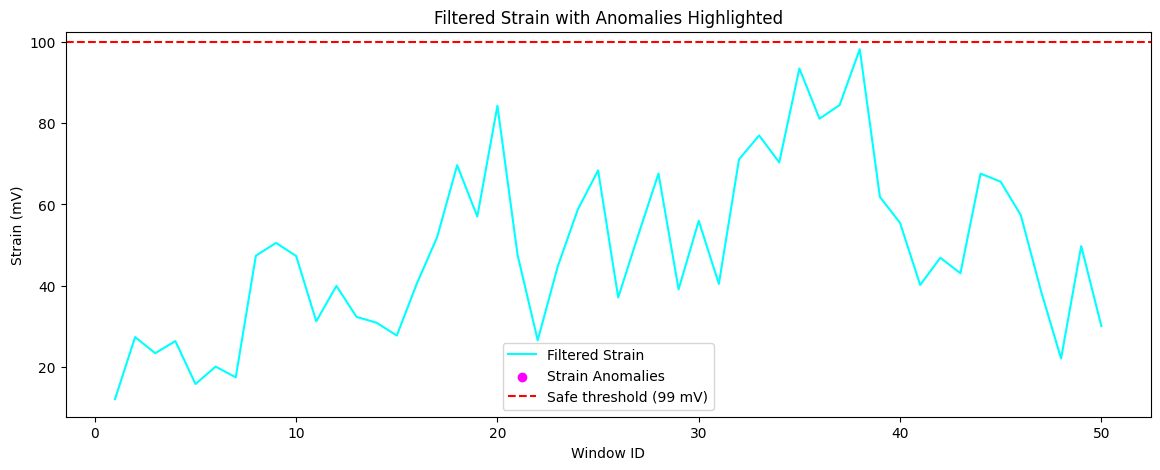

In [ ]:
# Plotting anomalies on the strain graph
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['filtered_strain'], label='Filtered Strain', color='cyan')
plt.scatter(df[df['strain_anomaly']]['window_id'], df[df['strain_anomaly']]['filtered_strain'], color='magenta', label='Strain Anomalies', zorder=5)
plt.axhline(y=strain_threshold, color='red', linestyle='--', label='Safe threshold (99 mV)') # Adding a horizontal line to indicate the safe threshold
plt.title('Filtered Strain with Anomalies Highlighted')
plt.xlabel('Window ID')
plt.ylabel('Strain (mV)')
plt.legend()
plt.show()

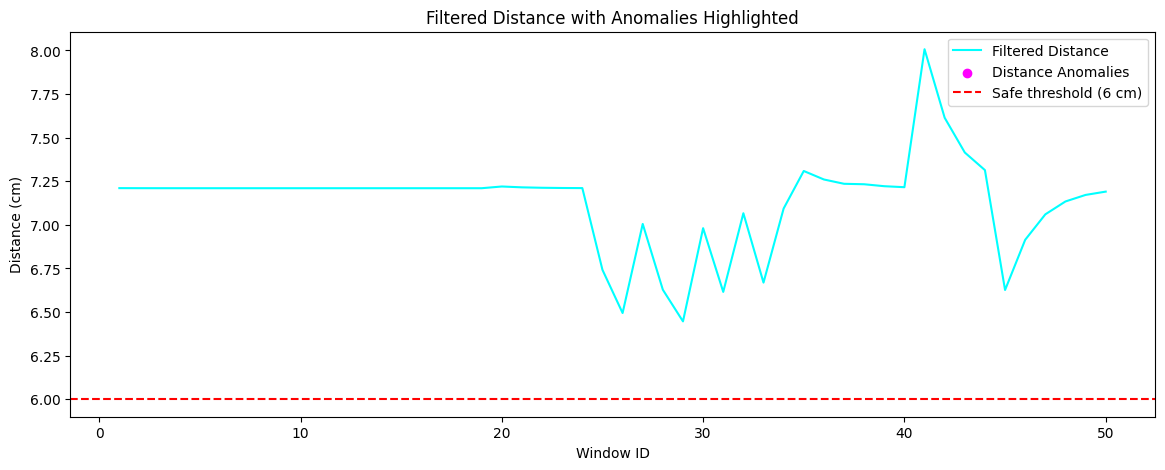

In [ ]:
# Plotting anomalies on the distance graph
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['filtered_distance'], label='Filtered Distance', color='cyan')
plt.scatter(df[df['distance_anomaly']]['window_id'], df[df['distance_anomaly']]['filtered_distance'], color='magenta', label='Distance Anomalies', zorder=5)
plt.axhline(y=us_threshold, color='red', linestyle='--', label='Safe threshold (6 cm)') # Adding a horizontal line to indicate the safe threshold
plt.title('Filtered Distance with Anomalies Highlighted')
plt.xlabel('Window ID')
plt.ylabel('Distance (cm)')
plt.legend()
plt.show()

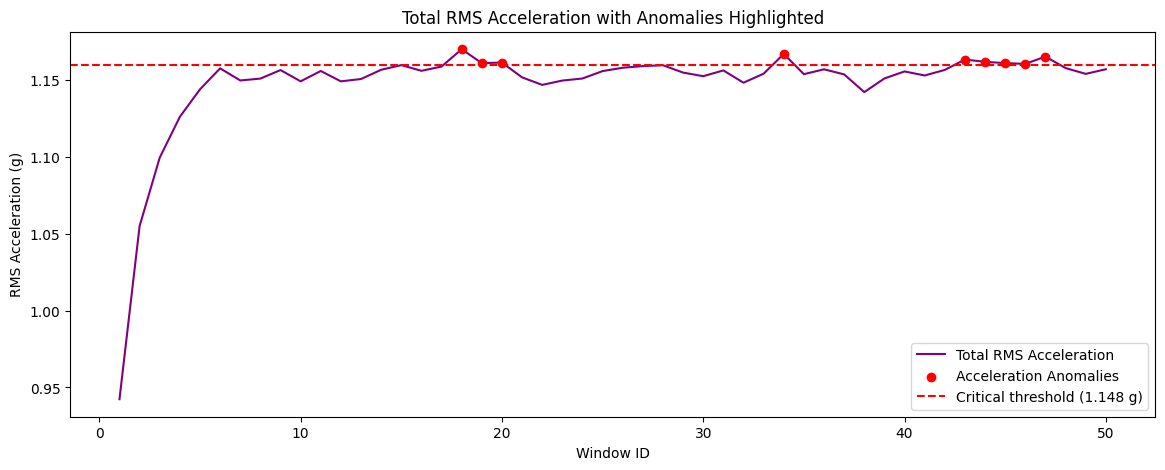

In [ ]:
# Plotting anomalies on the acceleration graph
plt.figure(figsize=(14, 5))
plt.plot(df['window_id'], df['accel_total_rms'], label='Total RMS Acceleration', color='purple')
plt.scatter(df[df['accel_anomaly']]['window_id'], df[df['accel_anomaly']]['accel_total_rms'], color='red', label='Acceleration Anomalies', zorder=5)
plt.axhline(y=accel_threshold, color='red', linestyle='--', label='Critical threshold (1.148 g)') # Adding a horizontal line to indicate the critical threshold
plt.title('Total RMS Acceleration with Anomalies Highlighted')
plt.xlabel('Window ID')
plt.ylabel('RMS Acceleration (g)')
plt.legend()
plt.show()

### Health Score Analysis


In [ ]:
# Health state classification based on detected anomalies

def classify_health_state(row):
    accel    = row['accel_anomaly']
    s1       = row['strain_anomaly']
    s2       = row['distance_anomaly']

    if accel and (s1 or s2):
        return 'Critical'
    if accel or (s1 and s2):
        return 'Warning'
    if s1 or s2:
        return 'Watch'
    return 'Healthy'
    
df['health_state'] = df.apply(classify_health_state, axis=1)
# Displaying the health state classification results
health_summary = df['health_state'].value_counts()
print("Health State Summary:")
print(health_summary)


Health State Summary:
health_state
Healthy    41
Warning     9
Name: count, dtype: int64


In [ ]:
# Displaying the health scores
df[['window_id','strain_anomaly','distance_anomaly','accel_anomaly' ,'health_state']]

,window_id,strain_anomaly,distance_anomaly,accel_anomaly,health_state
0,1,False,False,False,Healthy
1,2,False,False,False,Healthy
2,3,False,False,False,Healthy
3,4,False,False,False,Healthy
4,5,False,False,False,Healthy
5,6,False,False,False,Healthy
6,7,False,False,False,Healthy
7,8,False,False,False,Healthy
8,9,False,False,False,Healthy
9,10,False,False,False,Healthy


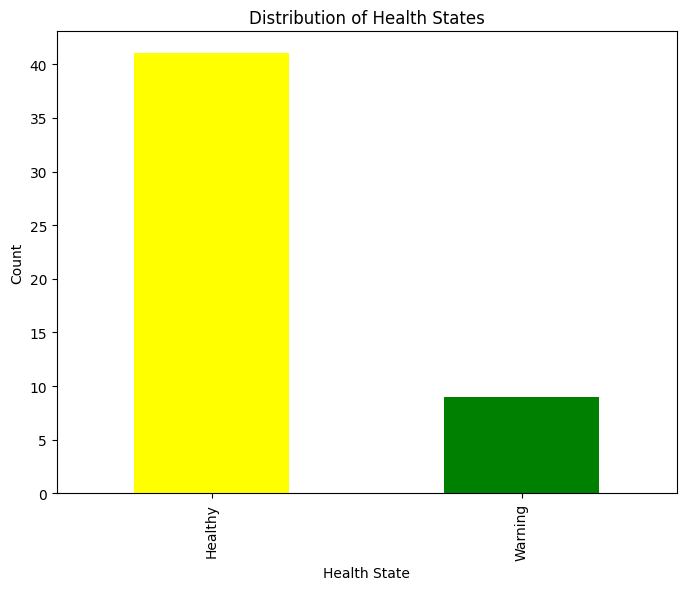

In [ ]:
# PLotting health state distribution
plt.figure(figsize=(8, 6))
health_summary.plot(kind='bar', color=['yellow','green','red','orange'])
plt.title('Distribution of Health States')
plt.xlabel('Health State')
plt.ylabel('Count')
plt.show()

In [ ]:
df.dropna(inplace=True) # Dropping any rows with NaN values that may have been introduced during filtering or anomaly detection
df.drop(['filtered_accel_x', 'filtered_accel_y', 'filtered_accel_z'], axis=1, inplace=True)
df.head()

,timestamp,window_id,filtered_strain,filtered_distance,accel_total_rms,accel_anomaly,strain_anomaly,distance_anomaly,health_state
0,2026-04-10 16:26:22.293,1,11.984818,7.210511,0.942312,False,False,False,Healthy
1,2026-04-10 16:26:28.655,2,27.298056,7.210222,1.054922,False,False,False,Healthy
2,2026-04-10 16:26:35.232,3,23.339248,7.210109,1.099448,False,False,False,Healthy
3,2026-04-10 16:26:41.901,4,26.320996,7.210055,1.126000,False,False,False,Healthy
4,2026-04-10 16:26:48.527,5,15.726185,7.210028,1.143870,False,False,False,Healthy


### Report Document

In [ ]:
# ── Convert dataframe rows to readable text entries ───────
def row_to_text(row):
    return f"""Bridge Sensor Report — Window {int(row['window_id'])}
Timestamp          : {row['timestamp']}
Health State       : {row['health_state']}
Filtered Strain    : {row['filtered_strain']:.4f} mV
Filtered Distance  : {row['filtered_distance']:.4f} cm
Total RMS Accel    : {row['accel_total_rms']:.6f} g
Acceleration Anomaly : {row['accel_anomaly']}
Strain Anomaly       : {row['strain_anomaly']}
Distance Anomaly     : {row['distance_anomaly']}
---"""

# ── Generate full report text ─────────────────────────────
report_lines = []

# Header summary
report_lines.append(f"""BRIDGE HEALTH MONITORING REPORT
Generated   : {df['timestamp'].iloc[-1]}
Total Windows : {len(df)}
Health State Distribution:
{df['health_state'].value_counts().to_string()}
========================================
""")

# One entry per row
for _, row in df.iterrows():
    report_lines.append(row_to_text(row))

full_report = "\n".join(report_lines)

# ── Save to .txt ──────────────────────────────────────────
import os
os.makedirs("../data", exist_ok=True)

txt_path = "../data/bridge_health_report.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write(full_report)

print(f"✅ Report saved to {txt_path}")
print(f"   Total characters : {len(full_report)}")
print(f"   Total windows    : {len(df)}")


✅ Report saved to ../data/bridge_health_report.txt
   Total characters : 14983
   Total windows    : 50

Preview:
BRIDGE HEALTH MONITORING REPORT
Generated   : 2026-04-10 16:31:51.852000
Total Windows : 50
Health State Distribution:
health_state
Healthy    41
Warning     9

Bridge Sensor Report — Window 1
Timestamp          : 2026-04-10 16:26:22.293000
Health State       : Healthy
Filtered Strain    : 11.9848 mV
Filtered Distance  : 7.2105 cm
Total RMS Accel    : 0.942312 g
Acceleration Anomaly : False
Strain Anomaly       : False
Distance Anomaly     : False
---
Bri


### Trend Analysis on Rolling Window History

In [ ]:
# # Performing Linear Regression to predict future conditions based on current sensor data
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split

# X = df[['accel_total_rms']]
# y = df['health_state'].apply(lambda x: 0 if x == 'Healthy' else (1 if x == 'Watch' else (2 if x == 'Warning' else 3)))  # Encoding health states as integers

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model = LinearRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# from sklearn.metrics import mean_squared_error, r2_score
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print(f"Mean Squared Error: {mse}")
# print(f"R^2 Score: {r2}")


In [ ]:
# Confidence Score on the predictions
# confidence_scores = model.predict(X)
# df['confidence_score'] = confidence_scores.clip(0, 1) # Clipping to [0, 1] range for interpretability
# print(df[['window_id', 'confidence_score']])